In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
import numpy as np

from utils.heatpipe_utils import generate_cfgs_seq, generate_cfg, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

import utils.sodium_properties as s_props

%config InlineBackend.figure_format = "retina"

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
with open("data/vapour_data.json", "r") as f:
    exp_data = json.load(f) 

    data_560  = exp_data["data_guoju_560"]
    data_1000 = exp_data["data_guoju_1000"]
    data_615  = exp_data["ivanovskii_615"]
    data_315  = exp_data["ivanovskii_315"]

In [ ]:
cfg_560  = generate_cfg(data_560 , 30, 100, data_560["bc"]["Q"])
cfg_1000 = generate_cfg(data_1000, 30, 100, data_1000["bc"]["Q"])

heatpipe_560  = Heatpipe(cfg_560)
heatpipe_1000 = Heatpipe(cfg_1000)
heatpipe_560.solid.variable_k  = True
heatpipe_1000.solid.variable_k = True

heatpipe_560_scaled  = Heatpipe(cfg_560)
heatpipe_1000_scaled = Heatpipe(cfg_1000)
heatpipe_560_scaled.solid.variable_k  = True
heatpipe_1000_scaled.solid.variable_k = True
heatpipe_560_scaled.set_loss_mult_factor(4/3)
heatpipe_1000_scaled.set_loss_mult_factor(4/3)
# heatpipe_560.solid.use_self_properties  = True
# heatpipe_1000.solid.use_self_properties = True

heatpipe_560.return_u = True
heatpipe_560_scaled.return_u = True
heatpipe_1000.return_u = True
heatpipe_1000_scaled.return_u = True

solver = Solver([heatpipe_560, heatpipe_1000, heatpipe_560_scaled, heatpipe_1000_scaled])
solver.fsolve()

Mesh warning: N_Z changed from 100 to 98
Running case 1 ...
fsolve message: The solution converged.
final residual L2 norm: 1.640e-06
Running case 2 ...
fsolve message: The solution converged.
final residual L2 norm: 5.828e-06
Running case 3 ...
fsolve message: The solution converged.
final residual L2 norm: 1.220e-06
Running case 4 ...
fsolve message: The solution converged.
final residual L2 norm: 4.400e-05


In [6]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": 30,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{siunitx}
        \usepackage{bm}
    """
})

colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB"
}

# cmap_orange = LinearSegmentedColormap.from_list(
#     "blue_to_white",
#     [colors["orange"], "white"]
# )


In [ ]:

def generate_ax(solutions, heatpipe, solutions_scaled, heatpipe_scaled, z_exp, T_exp):
    T_solid, u, mach, T_vap = solutions
    T_solid_scaled, u_scaled, mach_scaled, T_vap_scaled = solutions_scaled
    Z = heatpipe.solid.Z

    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    ax = fig.add_subplot(111)

    ax.grid(alpha=0.4, zorder=0)

    ax2 = ax.twinx()

    # Put temperature axis above Mach axis, but keep its background transparent.
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    # Blue models: lowest
    ax2.plot(Z, mach, label=r"Model Mach", color=colors["blue"], linewidth=3, zorder=1)
    ax2.plot(Z, mach_scaled, label=r"$\beta$-Model Mach", color=colors["blue"], linewidth=3, linestyle="--", zorder=1)
    ax2.set_ylabel("Mach number [-]")

    # Orange models: middle
    ax.plot(Z, T_vap, label=r"Model $T$", color=colors["orange"], linewidth=3, zorder=2)
    ax.plot(Z, T_vap_scaled, label=r"$\beta$-Model $T$", color=colors["orange"], linewidth=3, linestyle="--", zorder=2)

    # Experimental data: highest
    ax.scatter(z_exp, T_exp, label=r"Ivanovskii $T$", marker="s", color=colors["red"], s=100, zorder=3)

    ax.set_xlabel(r"Axial position $z$ [m]")
    ax.set_ylabel(r"Temperature $T$ [K]")

    # Combined legend
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    handles = lines_1 + lines_2
    labels = labels_1 + labels_2

    idx = labels.index(r"Ivanovskii $T$")
    handles = [handles[idx]] + handles[:idx] + handles[idx+1:]
    labels = [labels[idx]] + labels[:idx] + labels[idx+1:]

    legend = ax.legend(handles, labels)
    legend.set_zorder(10)

    return ax, ax2

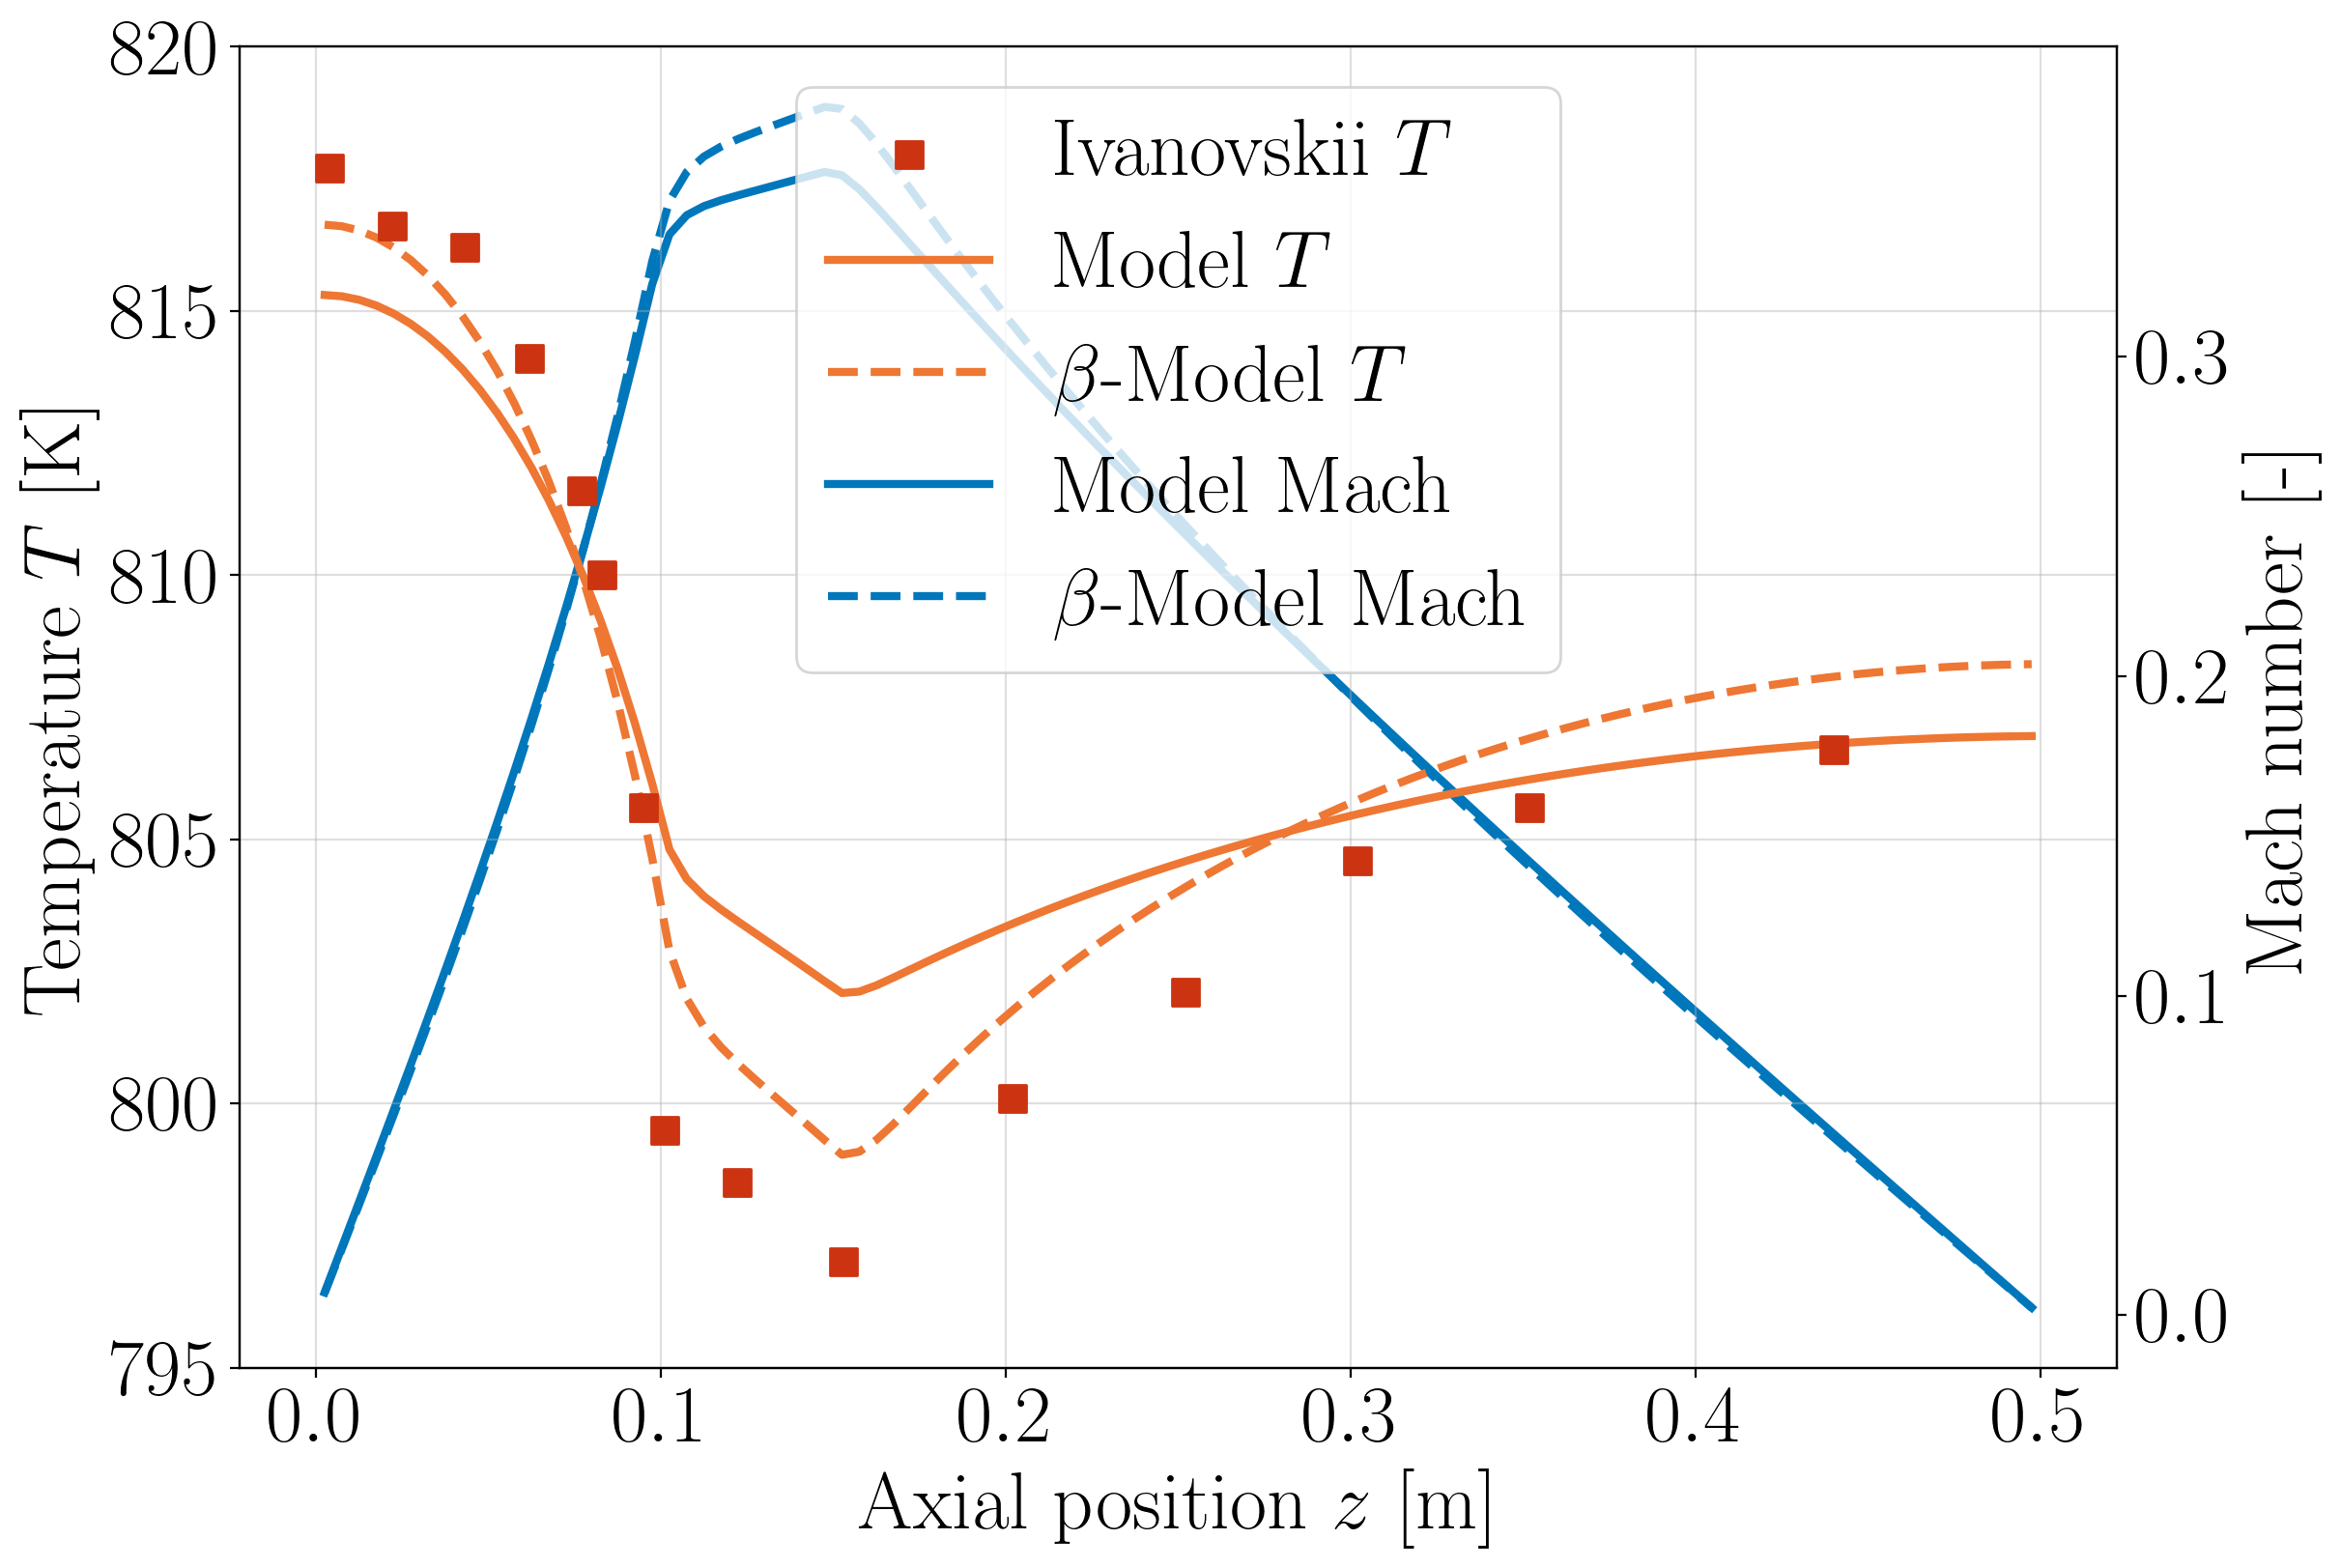

In [35]:
z_ivanovski_560 = np.array([0.004, 0.022, 0.043, 0.062, 0.077, 0.083, 0.095, 0.101, 0.122, 0.153, 0.202, 0.252, 0.302, 0.352, 0.440])
T_ivanovski_560 = np.array([817.7, 816.6, 816.2, 814.1, 811.6, 810.0, 805.6, 799.5, 798.5, 797.0, 800.1, 802.1, 804.6, 805.6, 806.7])

ax, ax_2 = generate_ax(solver.solutions[0], heatpipe_560, solver.solutions[2], heatpipe_560_scaled, z_ivanovski_560, T_ivanovski_560)

ax.set_ylim((795, 820))
# ax.set_title("Model validation against Ivanovskii's 560 W experiment")

plt.savefig("./outputs/report_figures/vapour_validations/Ivanovskii_560.pdf", bbox_inches="tight")
plt.show()

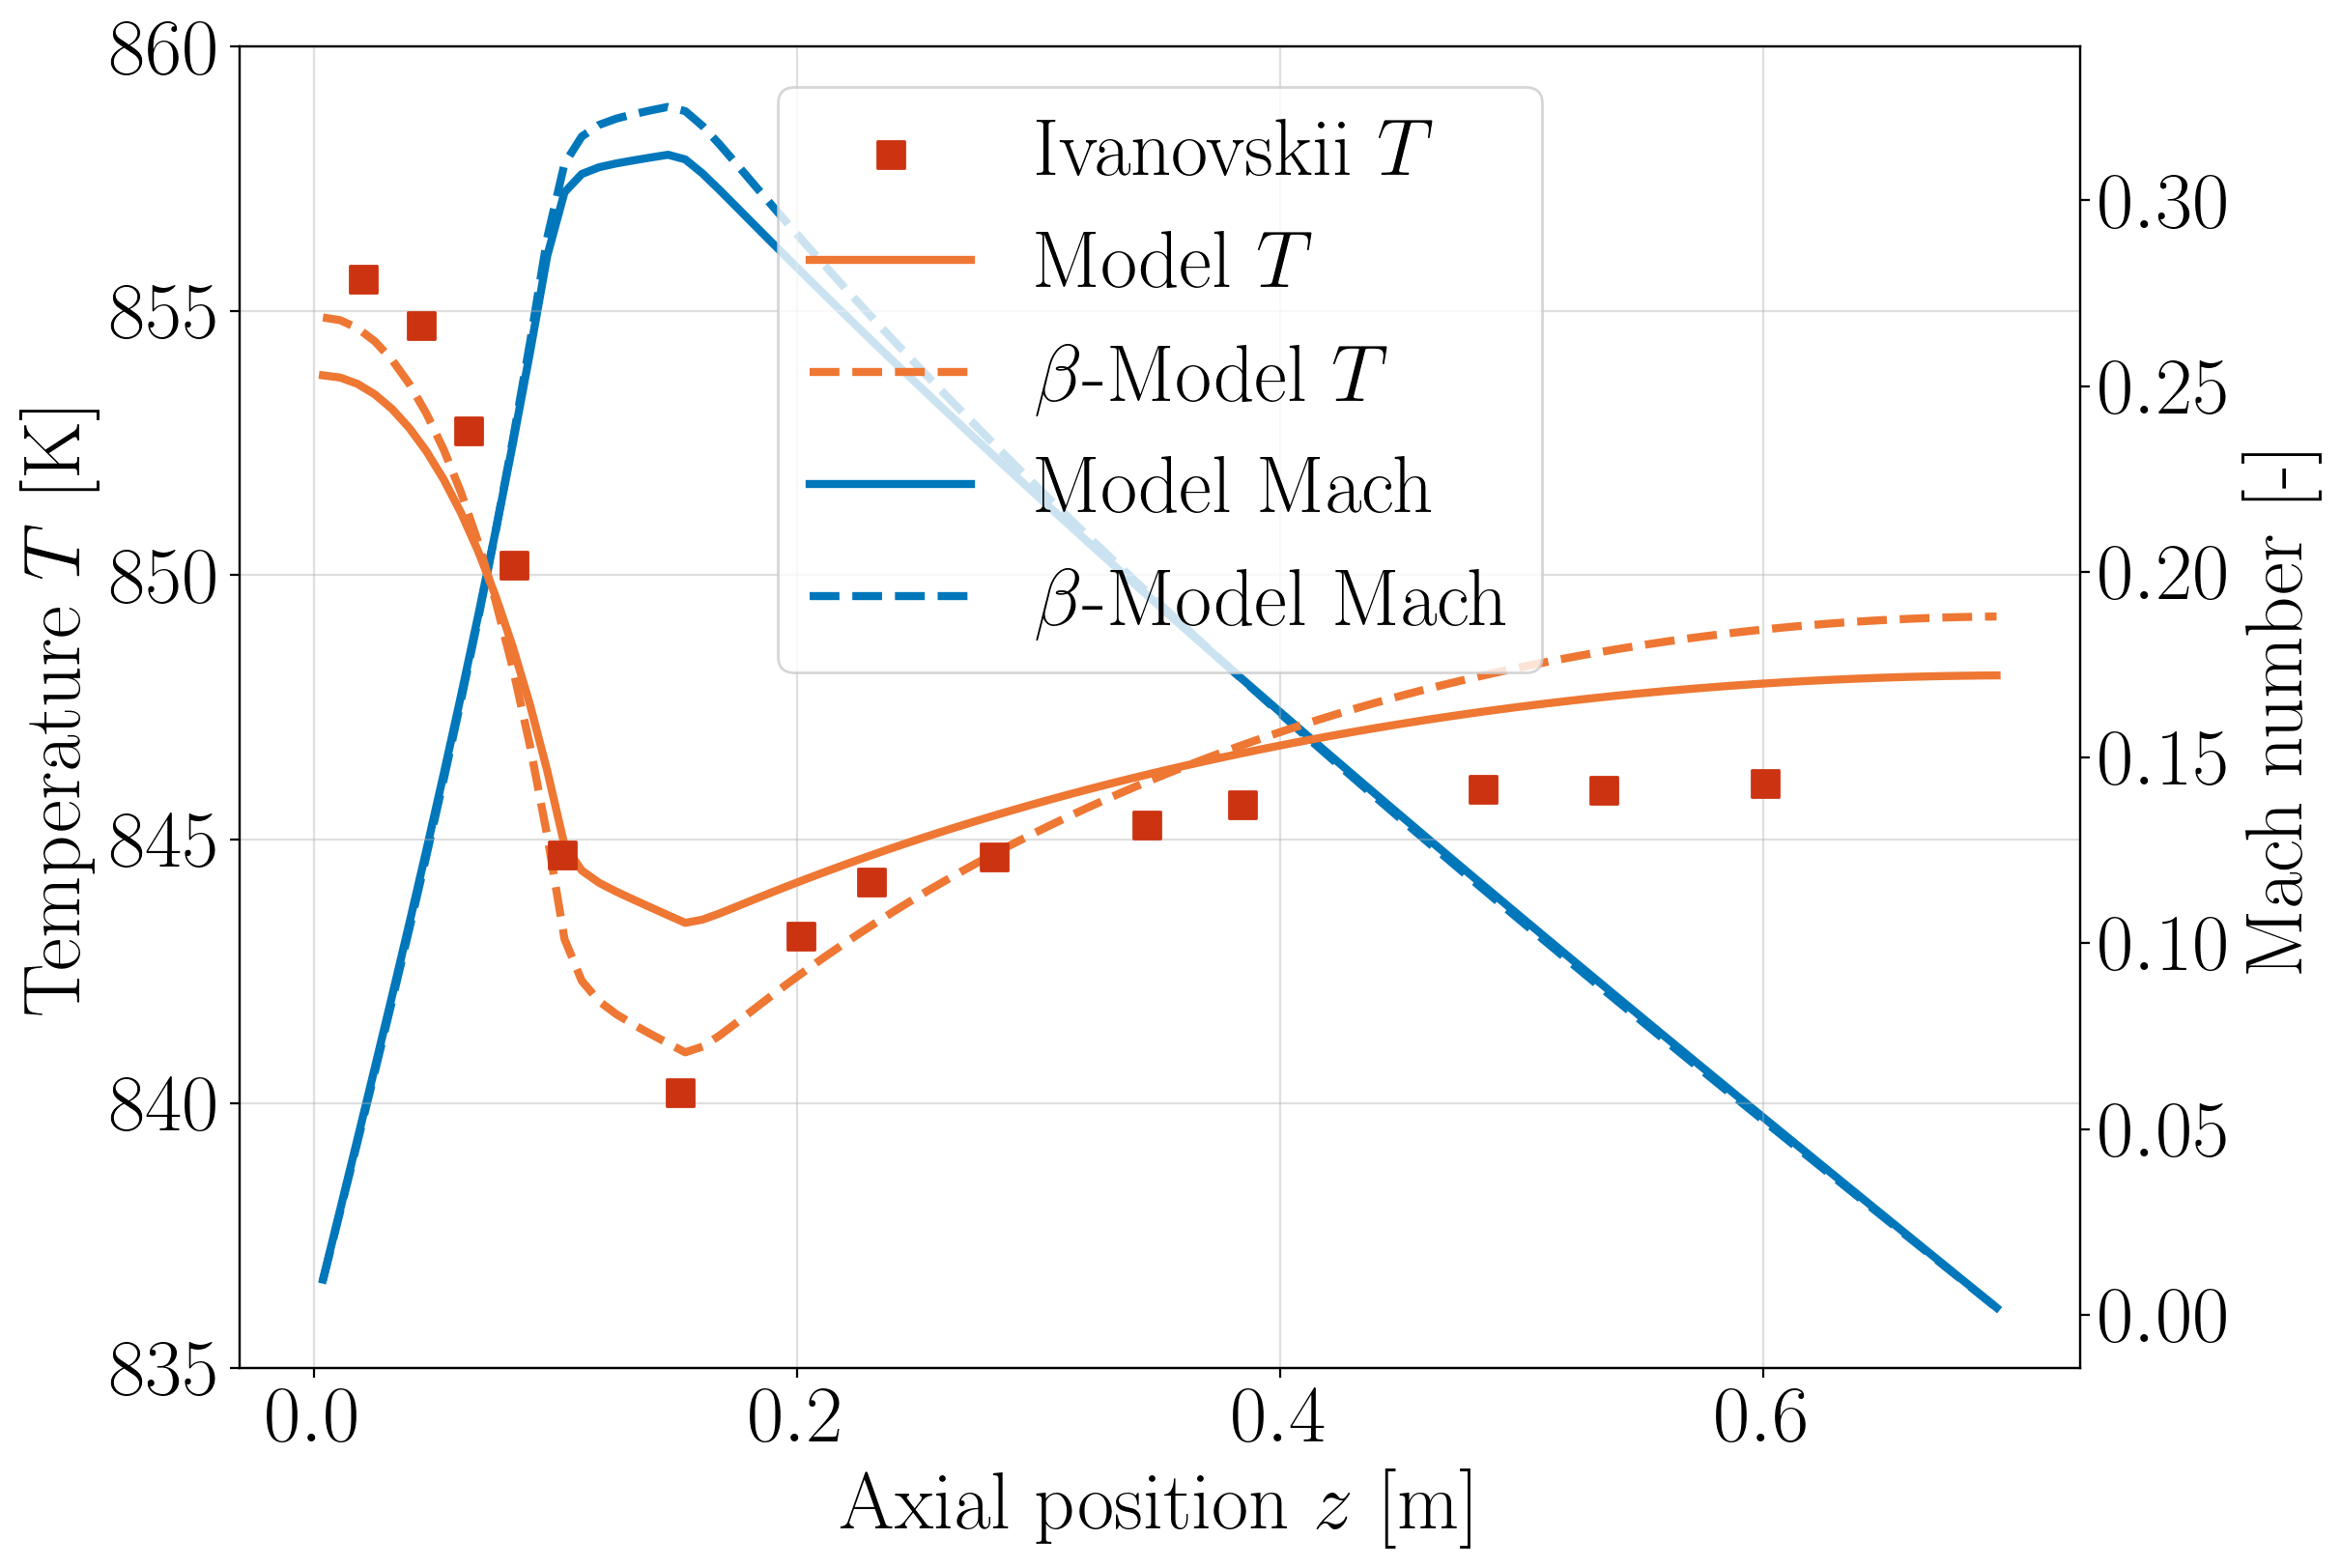

In [36]:
z_ivanovski_1000 = np.array([0.0204, 0.0444, 0.0639, 0.0825, 0.1027, 0.1515, 0.2015, 0.2305, 0.2814, 0.3447, 0.3843, 0.4840, 0.5338, 0.6008])
T_ivanovski_1000 = np.array([855.61, 854.73, 852.73, 850.19, 844.70, 840.20, 843.17, 844.19, 844.67, 845.27, 845.65, 845.95, 845.93, 846.06])

ax, ax_2 = generate_ax(solver.solutions[1], heatpipe_1000, solver.solutions[3], heatpipe_1000_scaled, z_ivanovski_1000, T_ivanovski_1000)

ax.set_ylim((835, 860))
# ax.set_title("Model validation against Ivanovskii's 1000 W experiment")

plt.savefig("./outputs/report_figures/vapour_validations/Ivanovskii_1000.pdf", bbox_inches="tight")
plt.show()

In [5]:
cfg_615 = generate_cfg(data_615, 30, 80, data_615["bc"]["Q"])
cfg_315 = generate_cfg(data_315, 30, 80, data_315["bc"]["Q"])

cfg_615.material.h_cond = 84.5
cfg_315.material.h_cond = 54.14

heatpipe_615 = Heatpipe(cfg_615)
heatpipe_315 = Heatpipe(cfg_315)
heatpipe_615.solid.variable_k = True
heatpipe_315.solid.variable_k = True

heatpipe_615_scaled = Heatpipe(cfg_615)
heatpipe_315_scaled = Heatpipe(cfg_315)
heatpipe_615_scaled.solid.variable_k = True
heatpipe_315_scaled.solid.variable_k = True
heatpipe_615_scaled.set_loss_mult_factor(4/3)
heatpipe_315_scaled.set_loss_mult_factor(4/3)
# heatpipe_615.solid.use_self_properties = True
# heatpipe_315.solid.use_self_properties = True

heatpipe_615.return_u = True
heatpipe_615_scaled.return_u = True
heatpipe_315.return_u = True
heatpipe_315_scaled.return_u = True

solver2 = Solver([heatpipe_615, heatpipe_315, heatpipe_615_scaled, heatpipe_315_scaled])
solver2.fsolve()

Mesh warning: N_R changed from 30 to 38
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 80 to 77
Running case 1 ...
fsolve message: The solution converged.
final residual L2 norm: 2.128e-05
Running case 2 ...
fsolve message: The solution converged.
final residual L2 norm: 7.426e-06
Running case 3 ...
fsolve message: The solution converged.
final residual L2 norm: 9.966e-06
Running case 4 ...
fsolve message: The solution converged.
final residual L2 norm: 6.098e-06


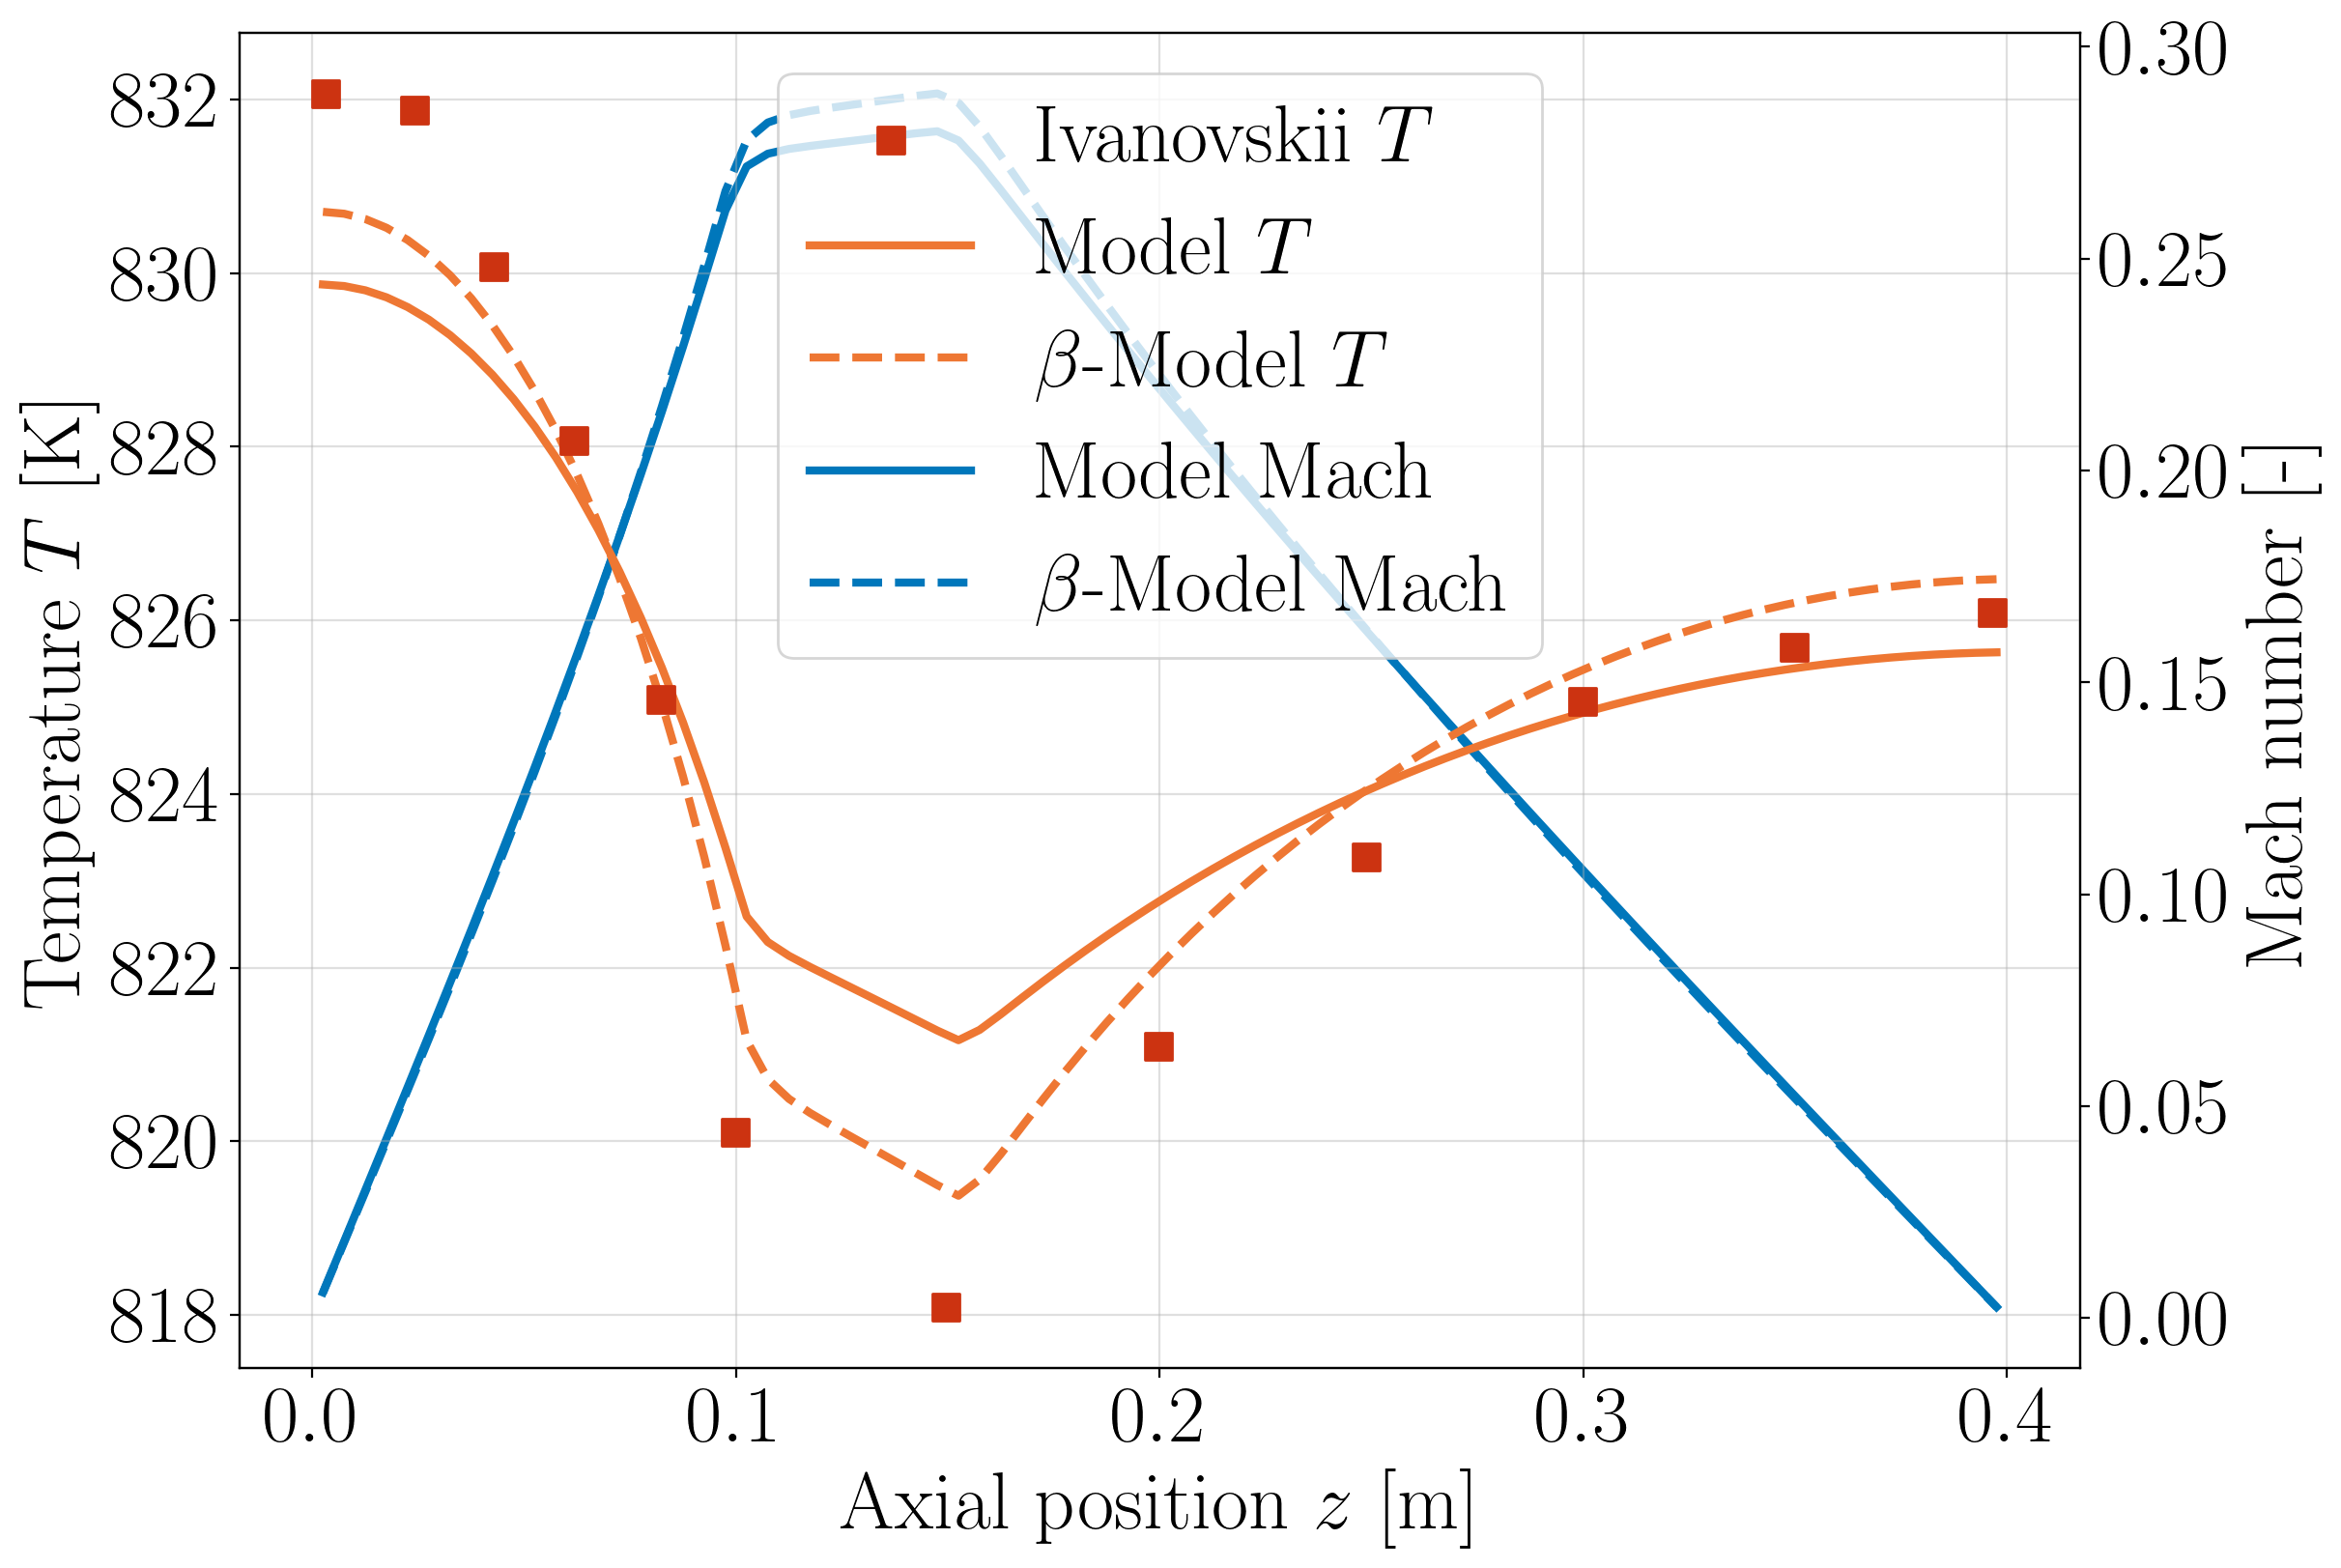

In [37]:
z_ivanovskii_615 = np.array([0.0032, 0.0241, 0.0427, 0.0617, 0.0823, 0.0997, 0.1496, 0.1998, 0.2488, 0.2997, 0.3497, 0.3965])
T_ivanovskii_615 = np.array([832.07, 831.88, 830.07, 828.07, 825.09, 820.10, 818.09, 821.09, 823.27, 825.07, 825.69, 826.09])

ax, ax_2 = generate_ax(solver2.solutions[0], heatpipe_615, solver2.solutions[2], heatpipe_615_scaled, z_ivanovskii_615, T_ivanovskii_615)

# ax.set_ylim((835, 860))
# ax.set_title("Model validation against Ivanovskii's 615 W experiment")

plt.savefig("./outputs/report_figures/vapour_validations/Ivanovskii_615.pdf", bbox_inches="tight")
plt.show()

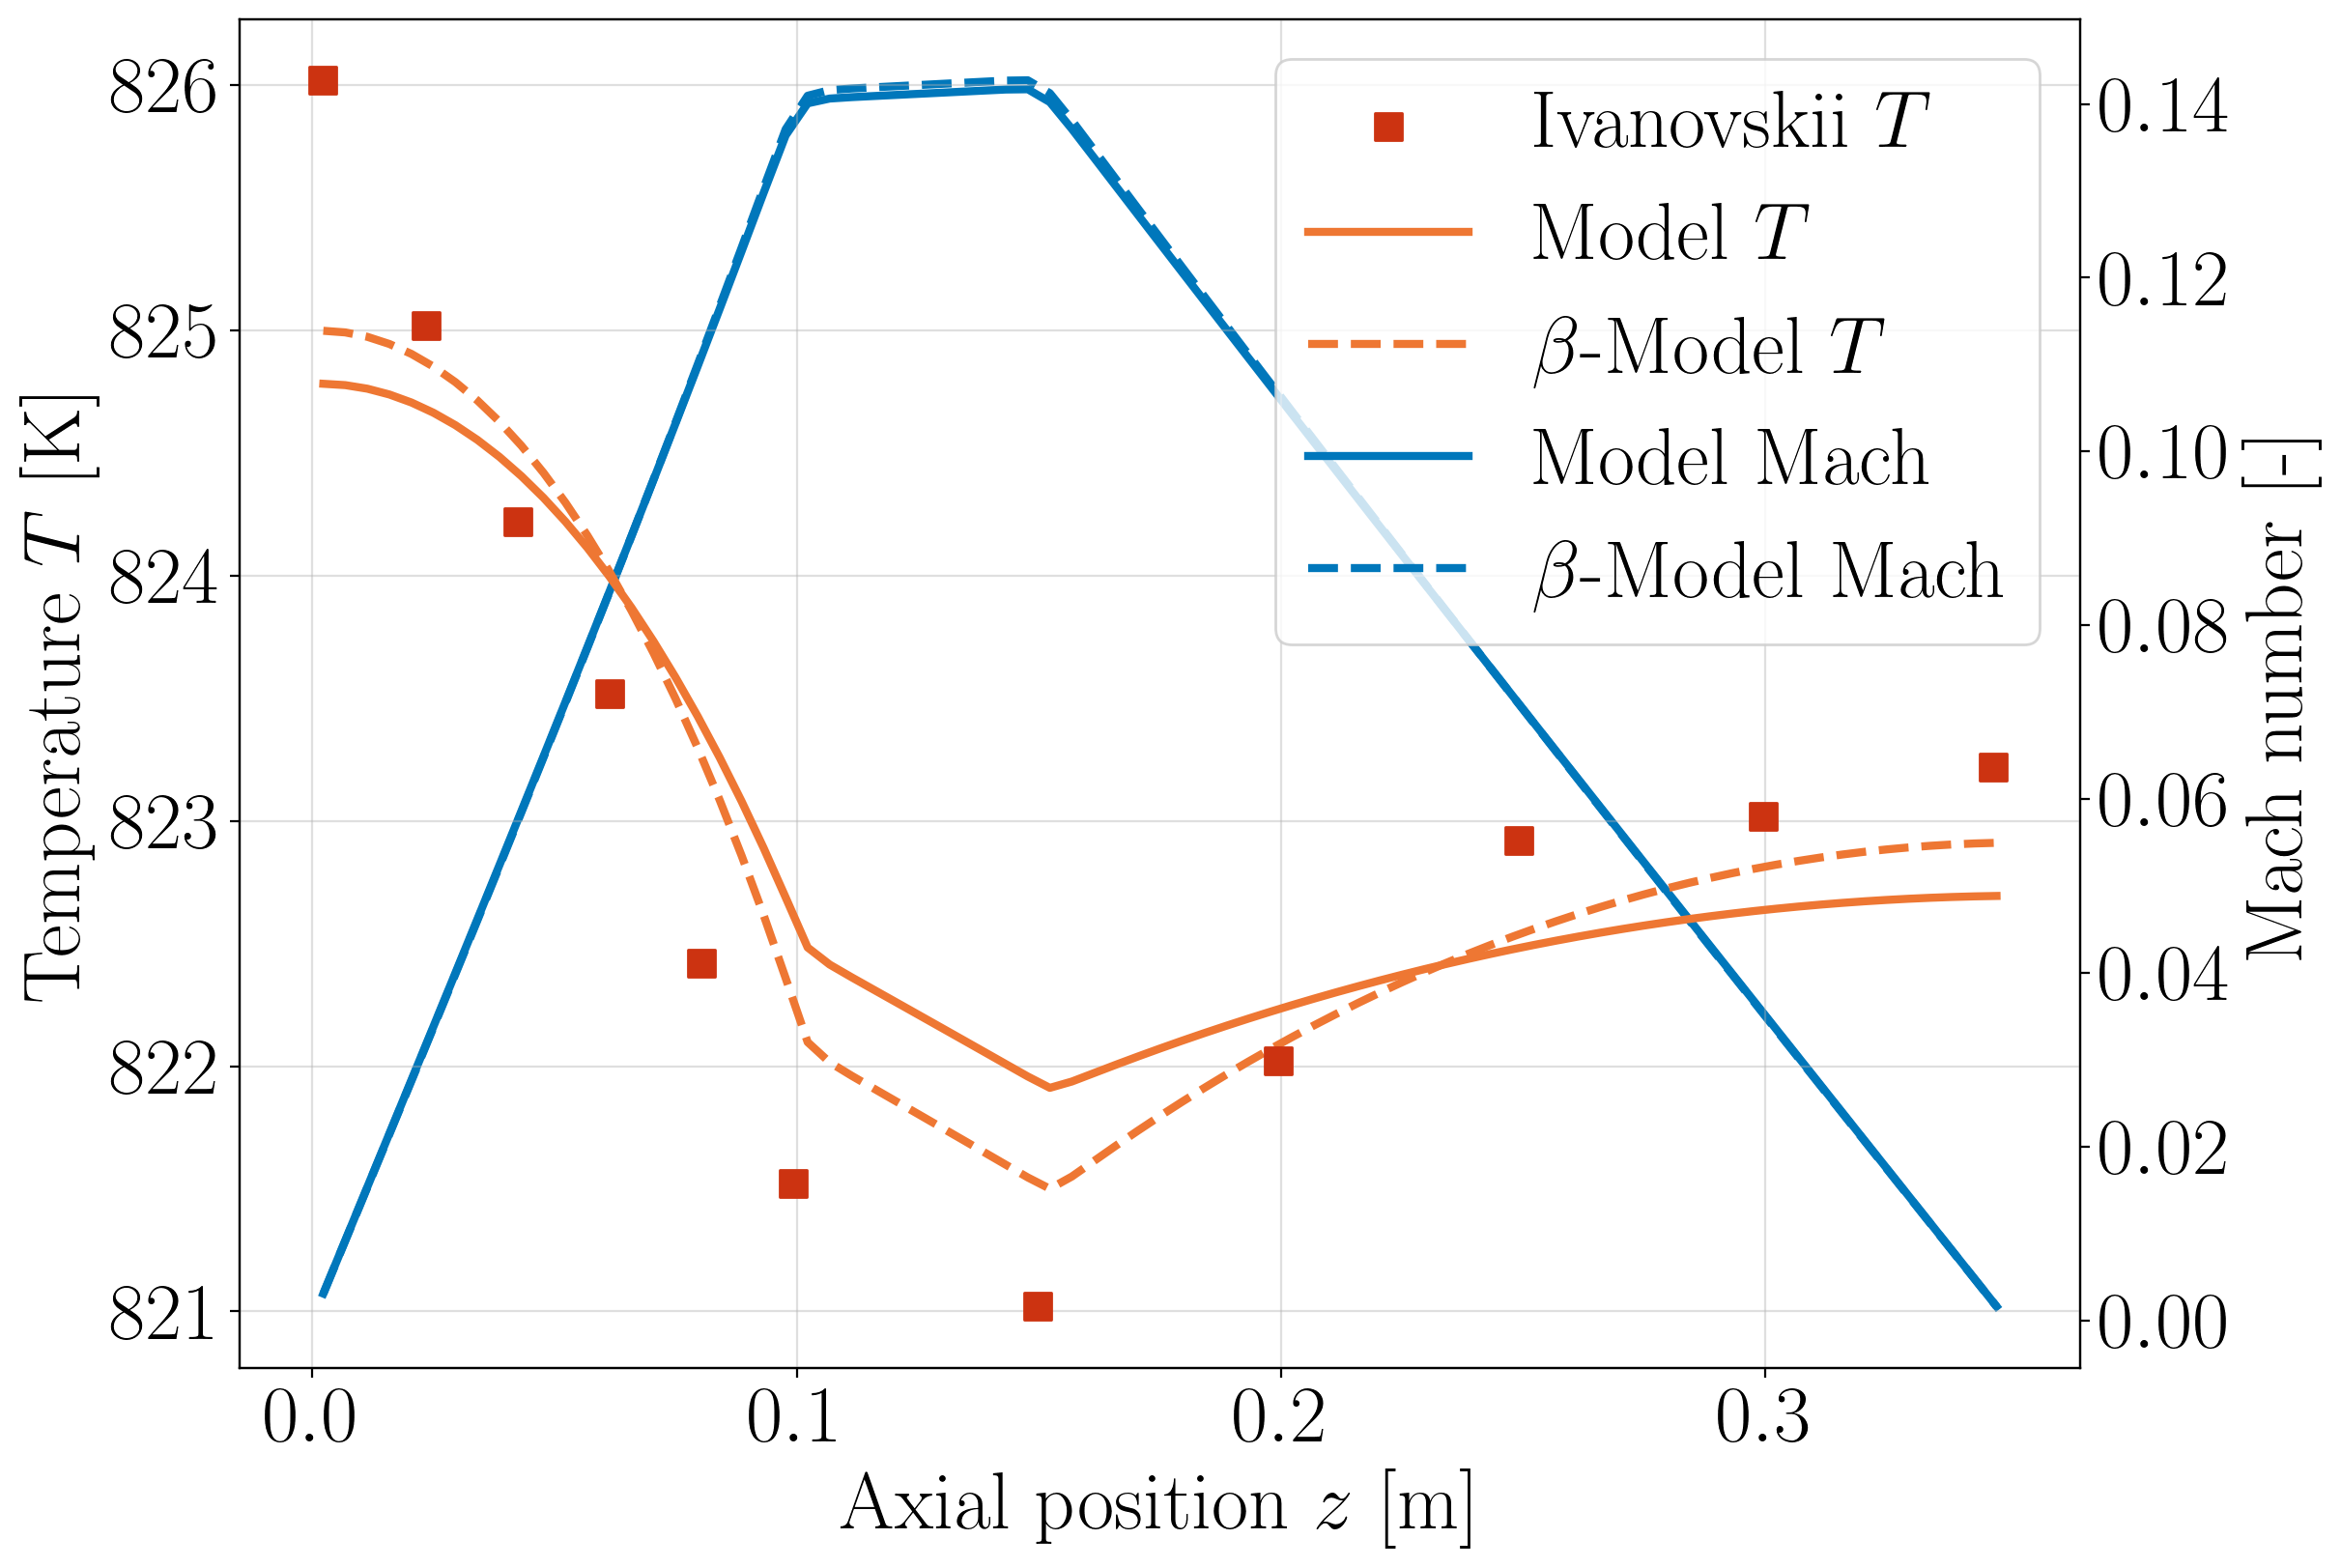

In [38]:
z_ivanovskii_315 = np.array([0.0022, 0.0234, 0.0424, 0.0613, 0.0803, 0.0993, 0.1497, 0.1995, 0.2491, 0.2996, 0.3471])
T_ivanovskii_315 = np.array([826.02, 825.02, 824.22, 823.52, 822.42, 821.52, 821.02, 822.02, 822.92, 823.02, 823.22])

ax, ax_2 = generate_ax(solver2.solutions[1], heatpipe_315, solver2.solutions[3], heatpipe_315_scaled, z_ivanovskii_315, T_ivanovskii_315)

# ax.set_ylim((835, 860))
# ax.set_title("Model validation against Ivanovskii's 315 W experiment")

plt.savefig("./outputs/report_figures/vapour_validations/Ivanovskii_315.pdf", bbox_inches="tight")
plt.show()

In [4]:
cfg_1000 = generate_cfg(data_1000, 30, 100, data_1000["bc"]["Q"])
cfg_560  = generate_cfg(data_560 , 30, 100, data_560["bc"]["Q"])
cfg_615  = generate_cfg(data_615 , 30, 100, data_615["bc"]["Q"])
cfg_315  = generate_cfg(data_315 , 30, 100, data_315["bc"]["Q"])

heatpipe_1000 = Heatpipe(cfg_1000)
heatpipe_560  = Heatpipe(cfg_560)
heatpipe_615  = Heatpipe(cfg_615)
heatpipe_315  = Heatpipe(cfg_315)
heatpipe_1000.solid.variable_k = True
heatpipe_560.solid.variable_k  = True
heatpipe_615.solid.variable_k  = True
heatpipe_315.solid.variable_k  = True

heatpipe_1000.return_u = True
heatpipe_560.return_u  = True
heatpipe_615.return_u  = True
heatpipe_315.return_u  = True

solver = Solver([heatpipe_1000, heatpipe_560, heatpipe_615, heatpipe_315])
solver.fsolve()

Mesh warning: N_Z changed from 100 to 98
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 100 to 104
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 100 to 98
Running case 1 ...
fsolve message: The solution converged.
final residual L2 norm: 5.834e-06
Running case 2 ...
fsolve message: The solution converged.
final residual L2 norm: 1.640e-06
Running case 3 ...
fsolve message: The solution converged.
final residual L2 norm: 2.099e-05
Running case 4 ...
fsolve message: The solution converged.
final residual L2 norm: 7.882e-06


In [5]:
cfg_1000 = generate_cfg(data_1000, 30, 100, data_1000["bc"]["Q"])
cfg_560  = generate_cfg(data_560 , 30, 100, data_560["bc"]["Q"])
cfg_615  = generate_cfg(data_615 , 30, 100, data_615["bc"]["Q"])
cfg_315  = generate_cfg(data_315 , 30, 100, data_315["bc"]["Q"])

heatpipe_1000_sat = Heatpipe(cfg_1000)
heatpipe_560_sat  = Heatpipe(cfg_560)
heatpipe_615_sat  = Heatpipe(cfg_615)
heatpipe_315_sat  = Heatpipe(cfg_315)

heatpipe_1000_sat.vapour.use_cc = True
heatpipe_560_sat.vapour.use_cc = True
heatpipe_615_sat.vapour.use_cc = True
heatpipe_315_sat.vapour.use_cc = True

heatpipe_1000_sat.solid.variable_k = True
heatpipe_560_sat.solid.variable_k  = True
heatpipe_615_sat.solid.variable_k  = True
heatpipe_315_sat.solid.variable_k  = True

heatpipe_1000_sat.return_u = True
heatpipe_560_sat.return_u  = True
heatpipe_615_sat.return_u  = True
heatpipe_315_sat.return_u  = True

solver_sat = Solver([heatpipe_1000_sat, heatpipe_560_sat, heatpipe_615_sat, heatpipe_315_sat])
solver_sat.fsolve()

Mesh warning: N_Z changed from 100 to 98
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 100 to 104
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 100 to 98
Running case 1 ...
fsolve message: The solution converged.
final residual L2 norm: 4.006e-05
Running case 2 ...
fsolve message: The solution converged.
final residual L2 norm: 2.763e-06
Running case 3 ...
fsolve message: The solution converged.
final residual L2 norm: 4.070e-06
Running case 4 ...
fsolve message: The solution converged.
final residual L2 norm: 4.629e-08


In [14]:
cfg_1000 = generate_cfg(data_1000, 30, 100, data_1000["bc"]["Q"])
cfg_560  = generate_cfg(data_560 , 30, 100, data_560["bc"]["Q"])
cfg_615  = generate_cfg(data_615 , 30, 100, data_615["bc"]["Q"])
cfg_315  = generate_cfg(data_315 , 30, 100, data_315["bc"]["Q"])

heatpipe_1000_sat_beta = Heatpipe(cfg_1000)
heatpipe_560_sat_beta  = Heatpipe(cfg_560)
heatpipe_615_sat_beta  = Heatpipe(cfg_615)
heatpipe_315_sat_beta  = Heatpipe(cfg_315)

heatpipe_1000_sat_beta.vapour.use_cc = True
heatpipe_560_sat_beta.vapour.use_cc = True
heatpipe_615_sat_beta.vapour.use_cc = True
heatpipe_315_sat_beta.vapour.use_cc = True

heatpipe_1000_sat_beta.solid.variable_k = True
heatpipe_560_sat_beta.solid.variable_k  = True
heatpipe_615_sat_beta.solid.variable_k  = True
heatpipe_315_sat_beta.solid.variable_k  = True

heatpipe_1000_sat_beta.return_u = True
heatpipe_560_sat_beta.return_u  = True
heatpipe_615_sat_beta.return_u  = True
heatpipe_315_sat_beta.return_u  = True

heatpipe_1000_sat_beta.vapour.loss_mult = 4/3
heatpipe_560_sat_beta.vapour.loss_mult = 4/3
heatpipe_615_sat_beta.vapour.loss_mult = 4/3
heatpipe_315_sat_beta.vapour.loss_mult = 4/3

solver_sat_beta = Solver([heatpipe_1000_sat_beta, heatpipe_560_sat_beta, heatpipe_615_sat_beta, heatpipe_315_sat_beta])
solver_sat_beta.fsolve()

Mesh warning: N_Z changed from 100 to 98
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 100 to 104
Mesh warning: N_R changed from 30 to 38
Mesh warning: N_Z changed from 100 to 98
Running case 1 ...
fsolve message: The solution converged.
final residual L2 norm: 5.720e-05
Running case 2 ...
fsolve message: The solution converged.
final residual L2 norm: 1.037e-05
Running case 3 ...
fsolve message: The solution converged.
final residual L2 norm: 3.904e-05
Running case 4 ...
fsolve message: The solution converged.
final residual L2 norm: 8.145e-08


In [47]:
z_ivanovski_560 = np.array([0.004, 0.022, 0.043, 0.062, 0.077, 0.083, 0.095, 0.101, 0.122, 0.153, 0.202, 0.252, 0.302, 0.352, 0.440])
T_ivanovski_560 = np.array([817.7, 816.6, 816.2, 814.1, 811.6, 810.0, 805.6, 799.5, 798.5, 797.0, 800.1, 802.1, 804.6, 805.6, 806.7])

z_ivanovski_1000 = np.array([0.0204, 0.0444, 0.0639, 0.0825, 0.1027, 0.1515, 0.2015, 0.2305, 0.2814, 0.3447, 0.3843, 0.4840, 0.5338, 0.6008])
T_ivanovski_1000 = np.array([855.61, 854.73, 852.73, 850.19, 844.70, 840.20, 843.17, 844.19, 844.67, 845.27, 845.65, 845.95, 845.93, 846.06])

z_ivanovskii_615 = np.array([0.0032, 0.0241, 0.0427, 0.0617, 0.0823, 0.0997, 0.1496, 0.1998, 0.2488, 0.2997, 0.3497, 0.3965])
T_ivanovskii_615 = np.array([832.07, 831.88, 830.07, 828.07, 825.09, 820.10, 818.09, 821.09, 823.27, 825.07, 825.69, 826.09])

z_ivanovskii_315 = np.array([0.0022, 0.0234, 0.0424, 0.0613, 0.0803, 0.0993, 0.1497, 0.1995, 0.2491, 0.2996, 0.3471])
T_ivanovskii_315 = np.array([826.02, 825.02, 824.22, 823.52, 822.42, 821.52, 821.02, 822.02, 822.92, 823.02, 823.22])

colors = {
    "black": "#000000",
    "blue": "#0072B2",
    "cyan": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "red": "#D55E00",
    "magenta": "#CC79A7",
    "yellow": "#F0E442"
}

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "Computer modern"
plt.rcParams["font.size"] = 36


def generate_ax(
    ax, solutions, heatpipe, mach_estimate,
    z_exp, T_exp, title=None, ylim=None,
    solutions_2=None,
    solutions_3=None,
):
    T_solid, u, mach, T_vap = solutions
    Z = heatpipe.solid.Z

    L_e = heatpipe.cfg.geometry.l_evap
    L_a = heatpipe.cfg.geometry.l_adiabatic
    L_c = heatpipe.cfg.geometry.l_cond

    ax.minorticks_on()
    ax.grid(which="major", alpha=0.40, linewidth=1.0, zorder=0)
    ax.grid(which="minor", alpha=0.20, linewidth=0.6, zorder=0)

    ax2 = ax.twinx()

    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    ax2.plot(
        Z, mach,
        label=r"$\beta$-Model Mach",
        color=colors["orange"],
        linewidth=3,
        linestyle="-.",
        zorder=1,
    )

    ax.plot(
        Z, T_vap,
        label=r"$\beta$-Model $T$",
        color=colors["cyan"],
        linewidth=3,
        linestyle="-.",
        zorder=2,
    )

    if solutions_2 is not None:
        T_solid_2, u_2, mach_2, T_vap_2 = solutions_2

        ax2.plot(
            Z, mach_2,
            label=r"Comp. Model Mach",
            color=colors["orange"],
            linewidth=3,
            linestyle="--",
            zorder=1,
            alpha=1
        )

        ax.plot(
            Z, T_vap_2,
            label=r"Comp. Model $T$",
            color=colors["cyan"],
            linewidth=3,
            linestyle="--",
            zorder=2,
            alpha=1
        )

    if solutions_3 is not None:
        T_solid_3, u_3, mach_3, T_vap_3 = solutions_3

        ax2.plot(
            Z, mach_3,
            label=r"Model 3 Mach",
            color=colors["orange"],
            linewidth=3,
            linestyle="-.",
            zorder=11,
            alpha=1
        )

        ax.plot(
            Z, T_vap_3,
            label=r"Model 3 $T$",
            color=colors["cyan"],
            linewidth=3,
            linestyle="-.",
            zorder=21,
            alpha=1
        )

    ax2.plot(
        Z, np.full_like(Z, mach_estimate),
        label="Mach estimate",
        color=colors["red"],
        linewidth=3,
        zorder=1.5,
    )

    ax2.set_ylabel("Mach number [-]")

    ax.scatter(
        z_exp, T_exp,
        label=r"Ivanovskii (1982) $T$",
        marker="s",
        color=colors["blue"],
        s=100,
        zorder=3,
    )

    if ylim is not None:
        ax.set_ylim(ylim)

    if L_e is not None and L_a is not None and L_c is not None:
        z0 = Z[0]
        z1 = z0 + L_e
        z2 = z0 + L_e + L_a
        z3 = z0 + L_e + L_a + L_c

        ax.axvline(z1, color="black", linestyle="--", linewidth=2.0, alpha=0.75, zorder=0.5)
        ax.axvline(z2, color="black", linestyle="--", linewidth=2.0, alpha=0.75, zorder=0.5)

        y_arrow = 0.075
        y_text = 0.105

        arrow_kw = dict(
            arrowstyle="<->",
            color="black",
            linewidth=2.0,
            shrinkA=0,
            shrinkB=0,
            mutation_scale=18,
        )

        ax.annotate(
            "",
            xy=(z1, y_arrow),
            xytext=(z0, y_arrow),
            xycoords=ax.get_xaxis_transform(),
            textcoords=ax.get_xaxis_transform(),
            arrowprops=arrow_kw,
            annotation_clip=False,
            zorder=0.7,
        )

        ax.annotate(
            "",
            xy=(z2, y_arrow),
            xytext=(z1, y_arrow),
            xycoords=ax.get_xaxis_transform(),
            textcoords=ax.get_xaxis_transform(),
            arrowprops=arrow_kw,
            annotation_clip=False,
            zorder=0.7,
        )

        ax.annotate(
            "",
            xy=(z3, y_arrow),
            xytext=(z2, y_arrow),
            xycoords=ax.get_xaxis_transform(),
            textcoords=ax.get_xaxis_transform(),
            arrowprops=arrow_kw,
            annotation_clip=False,
            zorder=0.7,
        )

        text_kw = dict(
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            zorder=0.8,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.5),
        )

        ax.text(0.5 * (z0 + z1), y_text, r"$l_e$", **text_kw)
        ax.text(0.5 * (z1 + z2), y_text, r"$l_a$", **text_kw)
        ax.text(0.5 * (z2 + z3), y_text, r"$l_c$", **text_kw)

    if title is not None:
        ax.text(
            0.72, 0.85, title,
            transform=ax.transAxes,
            ha="left",
            va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=0.85),
            zorder=20,
        )

    return ax, ax2

In [16]:
import pandas as pd

df_560 = pd.DataFrame.from_dict(data_560)
display(df_560)

,geometry,mesh,bc,material,wick,other
r_vapour,0.00700,NaN,NaN,NaN,NaN,NaN
delta_wick,0.00025,NaN,NaN,NaN,NaN,NaN
delta_gap,0.00025,NaN,NaN,NaN,NaN,NaN
delta_wall,0.00100,NaN,NaN,NaN,NaN,NaN
l_evap,0.10000,NaN,NaN,NaN,NaN,NaN
l_adiabatic,0.05000,NaN,NaN,NaN,NaN,NaN
l_cond,0.35000,NaN,NaN,NaN,NaN,NaN
N_R,NaN,20.0,NaN,NaN,NaN,NaN
N_Z,NaN,30.0,NaN,NaN,NaN,NaN
Temperature_BC,NaN,NaN,True,NaN,NaN,NaN


In [17]:
df_1000 = pd.DataFrame.from_dict(data_1000)
display(df_1000)

,geometry,mesh,bc,material,wick,other
r_vapour,0.00700,NaN,NaN,NaN,NaN,NaN
delta_wick,0.00025,NaN,NaN,NaN,NaN,NaN
delta_gap,0.00025,NaN,NaN,NaN,NaN,NaN
delta_wall,0.00100,NaN,NaN,NaN,NaN,NaN
l_evap,0.10000,NaN,NaN,NaN,NaN,NaN
l_adiabatic,0.05000,NaN,NaN,NaN,NaN,NaN
l_cond,0.55000,NaN,NaN,NaN,NaN,NaN
N_R,NaN,20.0,NaN,NaN,NaN,NaN
N_Z,NaN,30.0,NaN,NaN,NaN,NaN
Temperature_BC,NaN,NaN,True,NaN,NaN,NaN


In [18]:
df_615 = pd.DataFrame.from_dict(data_615)
print(cfg_615.material.h_cond)
display(df_615)

84.5


,geometry,bc,material,wick,other
r_vapour,0.0070,NaN,NaN,NaN,NaN
delta_wick,0.0004,NaN,NaN,NaN,NaN
delta_gap,0.0005,NaN,NaN,NaN,NaN
delta_wall,0.0010,NaN,NaN,NaN,NaN
l_evap,0.1000,NaN,NaN,NaN,NaN
l_adiabatic,0.0500,NaN,NaN,NaN,NaN
l_cond,0.2500,NaN,NaN,NaN,NaN
Temperature_BC,NaN,True,NaN,NaN,NaN
T_cond,NaN,300,NaN,NaN,NaN
T_op,NaN,850,NaN,NaN,NaN


In [19]:
df_315 = pd.DataFrame.from_dict(data_315)
print(cfg_315.material.h_cond)
display(df_315)

54.14


,geometry,bc,material,wick,other
r_vapour,0.0070,NaN,NaN,NaN,NaN
delta_wick,0.0004,NaN,NaN,NaN,NaN
delta_gap,0.0005,NaN,NaN,NaN,NaN
delta_wall,0.0010,NaN,NaN,NaN,NaN
l_evap,0.1000,NaN,NaN,NaN,NaN
l_adiabatic,0.0500,NaN,NaN,NaN,NaN
l_cond,0.2000,NaN,NaN,NaN,NaN
Temperature_BC,NaN,True,NaN,NaN,NaN
T_cond,NaN,300,NaN,NaN,NaN
T_op,NaN,850,NaN,NaN,NaN


In [20]:
# Experiment-based Mach estimate (independent of solver outputs)
# Assumption: peak vapour speed occurs near end of evaporator where mdot ~= Q/h_fg.

gamma = 5.0 / 3.0

experiments = {
    "560 W": {"Q": data_560["bc"]["Q"], "r_v": data_560["geometry"]["r_vapour"], "T_exp": T_ivanovski_560},
    "1000 W": {"Q": data_1000["bc"]["Q"], "r_v": data_1000["geometry"]["r_vapour"], "T_exp": T_ivanovski_1000},
    "615 W": {"Q": data_615["bc"]["Q"], "r_v": data_615["geometry"]["r_vapour"], "T_exp": T_ivanovskii_615},
    "315 W": {"Q": data_315["bc"]["Q"], "r_v": data_315["geometry"]["r_vapour"], "T_exp": T_ivanovskii_315},
}

mach_estimates = {}
max_mach_by_experiment = {}

for label, exp in experiments.items():
    T = np.asarray(exp["T_exp"], dtype=float)
    A_v = np.pi * exp["r_v"]**2

    h_fg = s_props.calculate_Na_h_fg(T)
    rho_v = s_props.calculate_Na_rho_v(T)
    p_v = s_props.calculate_Na_pressure_v(T)

    mdot = exp["Q"] / h_fg
    u_est = mdot / (rho_v * A_v)
    c_s = np.sqrt(gamma * p_v / rho_v)
    mach = u_est / c_s

    mach_estimates[label] = mach
    max_mach_by_experiment[label] = float(np.nanmax(mach))

max_mach_overall = float(np.nanmax(list(max_mach_by_experiment.values())))

print("Estimated max Mach by experiment (from experimental T, Q, geometry):")
for label, value in max_mach_by_experiment.items():
    print(f"  {label}: {value:.4f}")
print(f"Overall estimated max Mach: {max_mach_overall:.4f}")



Estimated max Mach by experiment (from experimental T, Q, geometry):
  560 W: 0.3948
  1000 W: 0.3301
  615 W: 0.2963
  315 W: 0.1442
Overall estimated max Mach: 0.3948


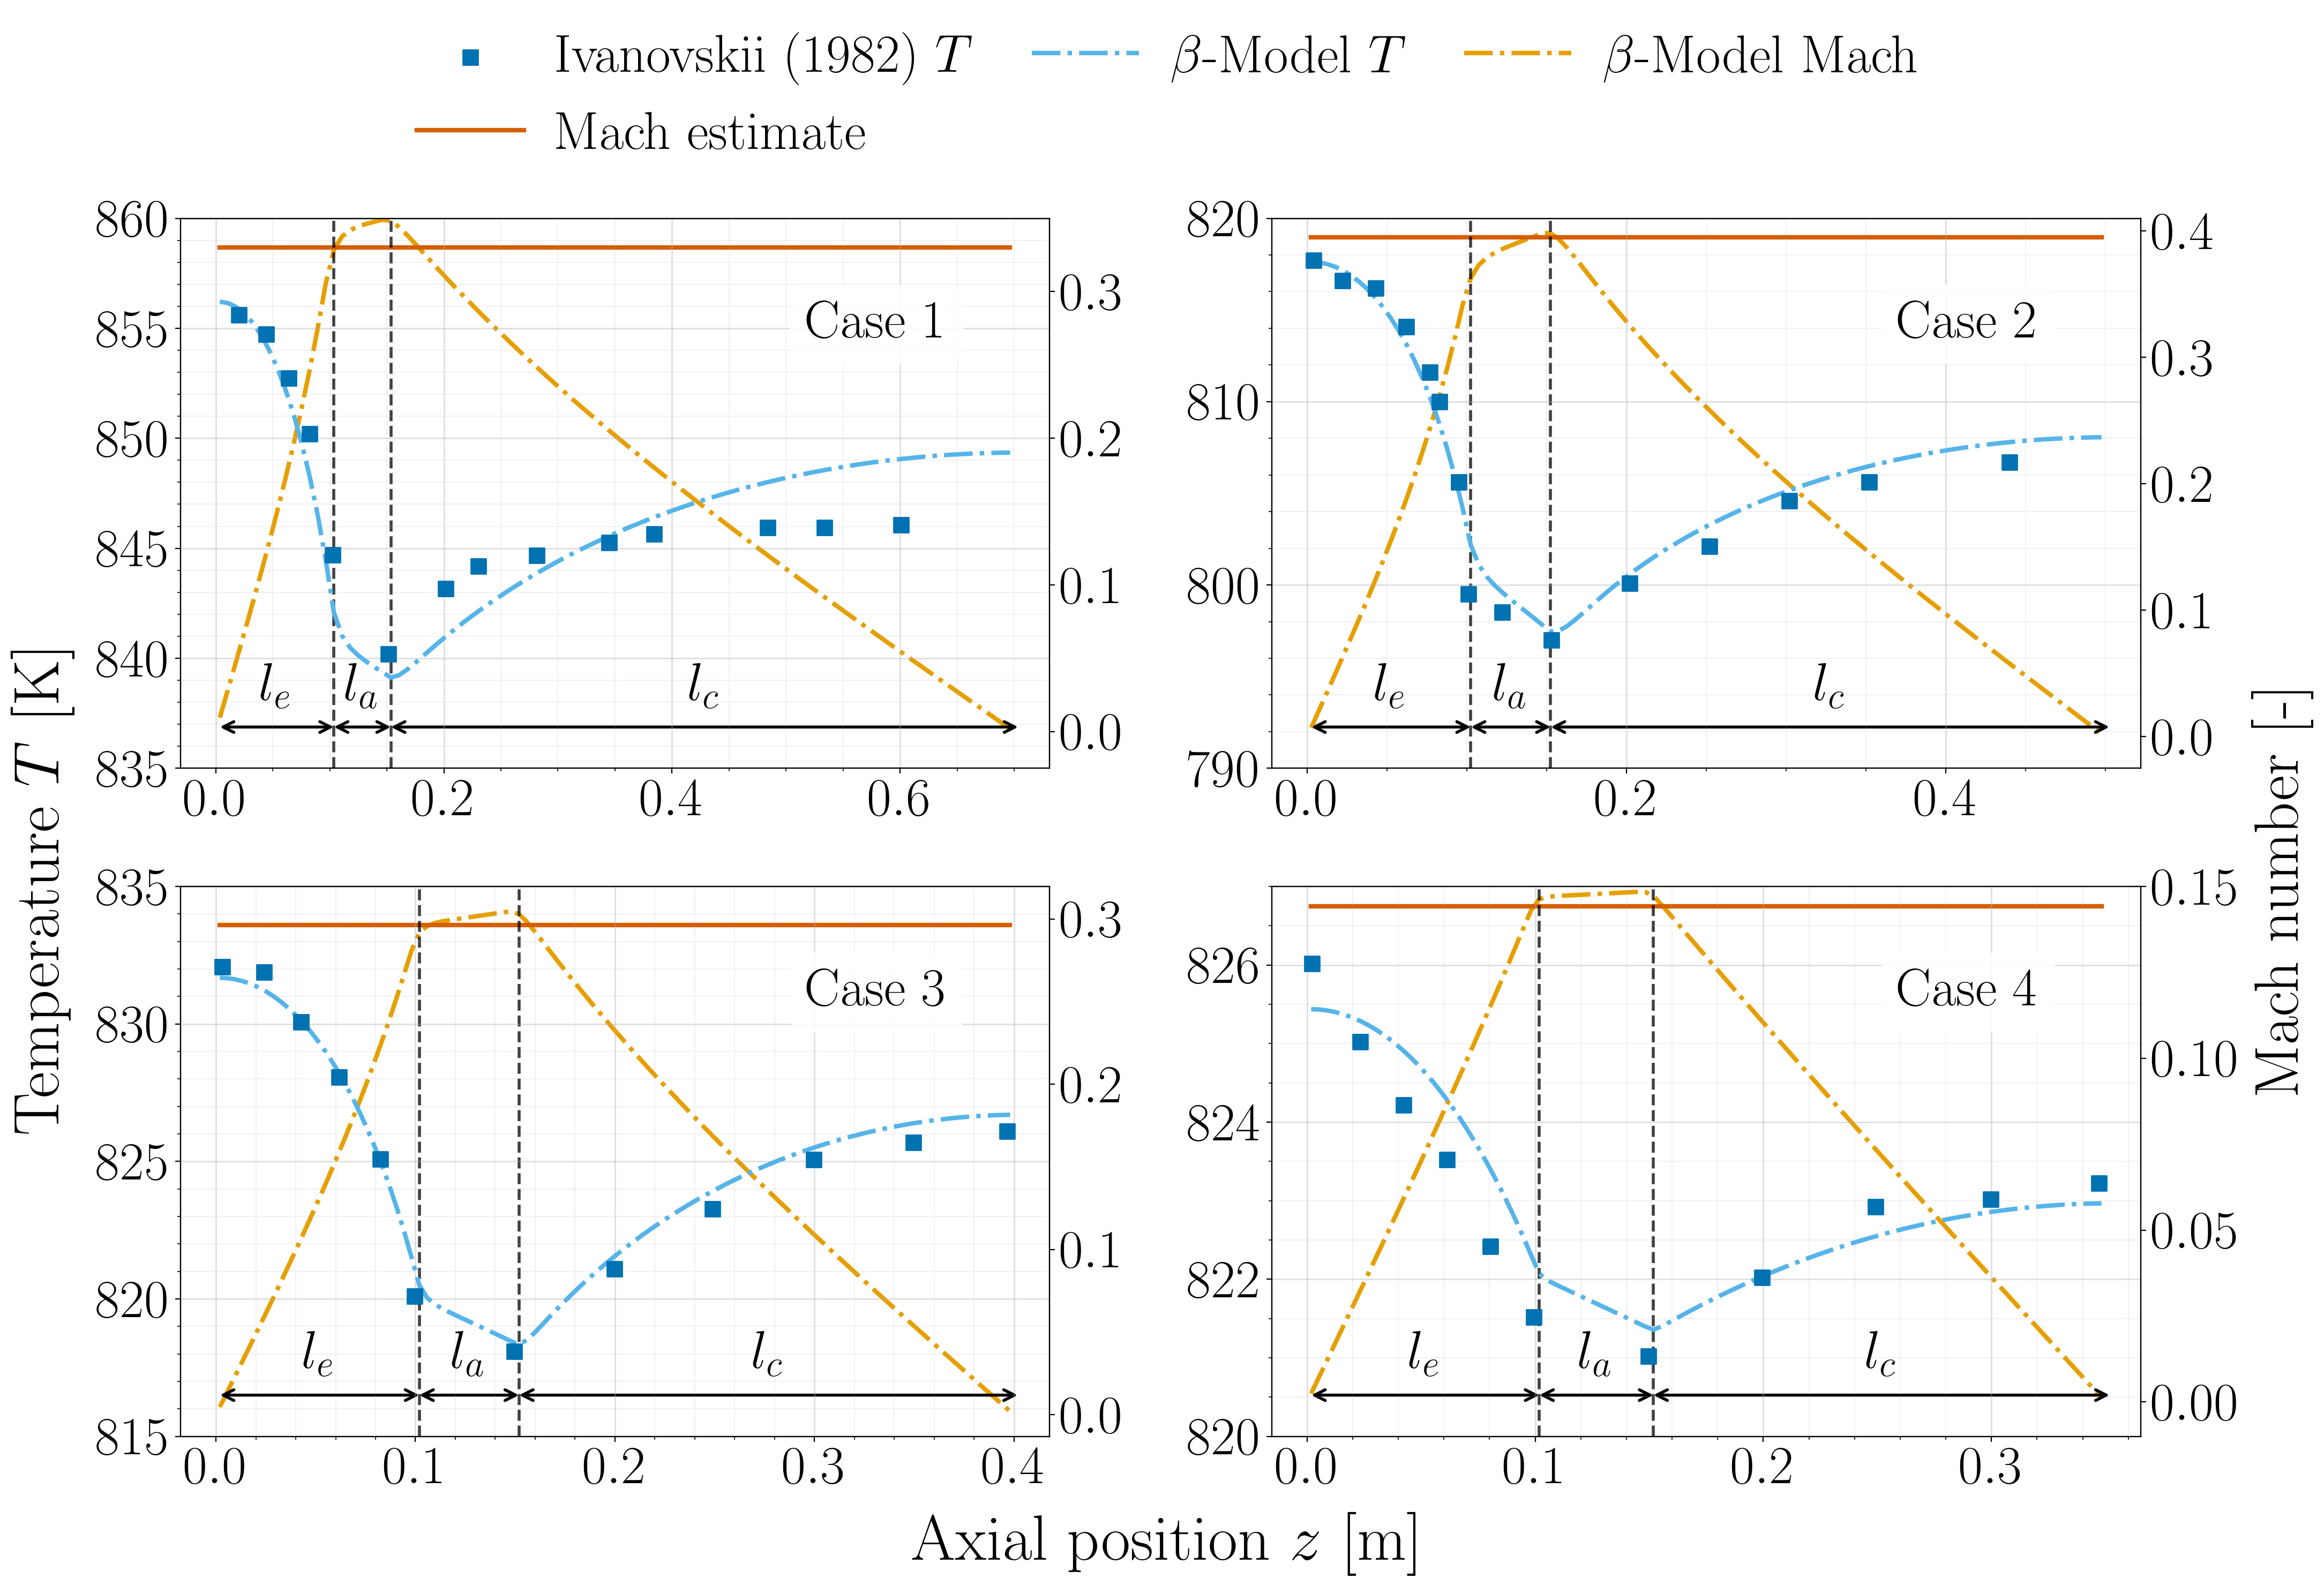

In [48]:
fig, axs = plt.subplots(2, 2, figsize=(20, 13), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0, h_pad=0.08, wspace=0.06, hspace=0.06)

ax_1000, ax2_1000 = generate_ax(
    axs[0, 0],
    solver_sat_beta.solutions[0],
    heatpipe_1000,
    max_mach_by_experiment["1000 W"],
    z_ivanovski_1000,
    T_ivanovski_1000,
    title=r"Case 1",
    ylim=(835, 860),
    # solutions_2 = solver_sat.solutions[0],
    # solutions_3 = solver_sat_beta.solutions[0]
)

ax_560, ax2_560 = generate_ax(
    axs[0, 1],
    solver_sat_beta.solutions[1],
    heatpipe_560,
    max_mach_by_experiment["560 W"],
    z_ivanovski_560,
    T_ivanovski_560,
    title=r"Case 2",
    ylim=(790, 820),
    # solutions_2 = solver_sat.solutions[1],
    # solutions_3 = solver_sat_beta.solutions[1]
)

ax_615, ax2_615 = generate_ax(
    axs[1, 0],
    solver_sat_beta.solutions[2],
    heatpipe_615,
    max_mach_by_experiment["615 W"],
    z_ivanovskii_615,
    T_ivanovskii_615,
    title=r"Case 3",
    ylim=(815, 835),
    # solutions_2 = solver_sat.solutions[2],
    # solutions_3 = solver_sat_beta.solutions[2]
)

ax_315, ax2_315 = generate_ax(
    axs[1, 1],
    solver_sat_beta.solutions[3],
    heatpipe_315,
    max_mach_by_experiment["315 W"],
    z_ivanovskii_315,
    T_ivanovskii_315,
    title=r"Case 4",
    ylim=(820, 827),
    # solutions_2 = solver_sat.solutions[3],
    # solutions_3 = solver_sat_beta.solutions[3]
)

# ax_315.yaxis.set_major_locator(MultipleLocator(1))
ax2_315.yaxis.set_major_locator(MultipleLocator(0.05))
ax2_315.set_ylim((-0.01, 0.15))
ax2_1000.set_ylim((-0.025, 0.35))
ax2_560.set_ylim((-0.025, 0.41))

for ax in axs[0, :]:
    ax.set_xlabel("")

for ax in axs[:, 1]:
    ax.set_ylabel("")

for ax2 in [ax2_1000, ax2_560, ax2_615, ax2_315]:
    ax2.set_ylabel("")

fig.supylabel(r"Temperature $T$ [K]", x=-0.04)
fig.supxlabel(r"Axial position $z$ [m]")

fig.text(
    1.02, 0.5,
    r"Mach number [-]",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=42,
)

lines_1, labels_1 = ax_560.get_legend_handles_labels()
lines_2, labels_2 = ax2_560.get_legend_handles_labels()

handles = lines_1 + lines_2
labels = labels_1 + labels_2

idx = labels.index(r"Ivanovskii (1982) $T$")
handles = [handles[idx]] + handles[:idx] + handles[idx + 1:]
labels = [labels[idx]] + labels[:idx] + labels[idx + 1:]

# Desired visual layout:
# row 1: handles[0], handles[1], handles[2]
# row 2: handles[3], handles[4], handles[5]
# handles = [
#     handles[0], handles[5],
#     handles[1], handles[2],
#     handles[3], handles[4],
# ]

# labels = [
#     labels[0], labels[5],
#     labels[1], labels[2],
#     labels[3], labels[4],
# ]

handles = [
    handles[0], handles[3], handles[1], handles[2]
]

labels = [
    labels[0], labels[3], labels[1], labels[2]
]

legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    ncol=3,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.0,
    handletextpad=0.6,
    borderaxespad=0.0,
)

fig.savefig("./outputs/report_figures/vapour_validations/Ivanovskii_2x2_momentum_corr.pdf", bbox_inches="tight")
plt.show()